# PhonologyBench for Russian 

I asked HU-LLM Mistral Large and ChatGPT-4o to count syllables in Russian words. Inspired by [PhonologyBench: Evaluating Phonological Skills of Large Language Models](https://aclanthology.org/2024.knowllm-1.1/) (Suvarna et al., KnowLLM 2024). 


## Counting syllables in words
The idea is to test how good are HU-LLM and ChatGPT-4o in counting syllables in Russian words. I took words with different number of syllables from [this web](https://slogi.su/1). I expect it to be quite good in this task as there is a clear algorithm how to identify a syllable in a Russian word. 

The preprocessed files with words are located in `words_folder`. The code below: 

- reads each file from the folder
- counts how many words are in each file 
- creates a big csv with all words and syllables count

In [4]:
import os
import pandas as pd

dir_path = os.getcwd()
print(dir_path)

/Users/maria.onoeva/Desktop/new_folder/GitHub/nlp-repo/Ru_phono_bench


In [11]:
dfs = {}

words_folder = dir_path + "/words_folder"

# Loop through all .txt files in the folder as above
for filename in os.listdir(words_folder):
    if filename.endswith('.txt'):
        file_path = os.path.join(words_folder, filename)

        with open(file_path, 'r') as file:
            words = file.read().split(', ')
            length = len(words)

        print(f"Words in {filename}: {length}")

        # Create a DataFrame
        df = pd.DataFrame(words, columns=['word'])

        # Extract syllable count from filename (e.g., 'words_3.txt' -> 3)
        syllable_count = int(''.join([d for d in filename if d.isdigit()]))

        # Add the syllable count column
        df['syllable'] = syllable_count

        # Store in dictionary using filename without extension as key
        key = os.path.splitext(filename)[0]
        dfs[key] = df

# combine all DataFrames into one big one
combined_df = pd.concat(dfs.values(), ignore_index=True)

# saving as csv
combined_df.to_csv(words_folder + '/' +'combined_df.csv') 

Words in words_8.txt: 208
Words in words_9.txt: 144
Words in words_4.txt: 286
Words in words_5.txt: 278
Words in words_7.txt: 257
Words in words_6.txt: 272
Words in words_2.txt: 296
Words in words_3.txt: 298
Words in words_1.txt: 270


In [7]:
combined_df.count()

word        2309
syllable    2309
dtype: int64

Now I create 4 random samples of 250 words from the big csv and prompt it to the models.

In [8]:
import numpy as np

sample_df_1000 = combined_df.sample(n=1000, random_state=420)

# Split into 4 approximately equal parts
split_dfs = np.array_split(sample_df_1000, 4)

# If you want lists instead of DataFrames:
split_lists = [subdf['word'].tolist() for subdf in split_dfs]

# Access the 4 random non-overlapping lists:
list1, list2, list3, list4 = split_lists

/Users/maria.onoeva/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [12]:
sample_df_1000.to_csv(words_folder + '/sample_df_1000.csv')

### HU-LLM 
I prompted HU-LLM via its API. 1000 in one batch seems too much, so I did it in four parts. It took 17 minutes to run. In addition to that, it worked within HU network only. The output is in `HU-LLM` folder.

In [51]:
from gradio_client import Client

for i in split_lists: 
    client = Client("https://llm1-compute.cms.hu-berlin.de/")
    result_list = client.predict(
		param_0=f"Please count syllables in these Russian words {i}",
		api_name="/chat"
)
    with open("sample_1000_result.txt", "a") as file:
        file.write(result_list)


Loaded as API: https://llm1-compute.cms.hu-berlin.de/ ✔
Loaded as API: https://llm1-compute.cms.hu-berlin.de/ ✔
Loaded as API: https://llm1-compute.cms.hu-berlin.de/ ✔
Loaded as API: https://llm1-compute.cms.hu-berlin.de/ ✔


Before assessing the results, I need to clean the result file `sample_1000_result.txt`. I manually removed all except results and saved to a new file `sample_1000_result_clean.txt`. Now I also need to remove numbers and replace `' - '` pattern with comma. Saving to `cleaned_output.csv`.

In [19]:
import re

HU_folder = dir_path + "/HU-LLM"

pattern1 = re.compile(r"\d+\.\s") # this will remove a number from the beginning of the line
pattern2 = re.compile(r"\s*-\s*") # replaces " - " pattern 

cleaned_rows = []

with open(HU_folder + '/' + "sample_1000_result_clean.txt", "r") as file:
    for line in file:
        line = pattern1.sub("", line)
        line = pattern2.sub(",", line)
        cleaned_line = line.strip()
        row = cleaned_line.split(",")  # split into columns
        cleaned_rows.append(row)

# Create DataFrame and save to CSV
cleaned_output = pd.DataFrame(cleaned_rows)
cleaned_output.to_csv(HU_folder + "/cleaned_output_HU.csv", index=False, header=False)

In [20]:
cleaned_output.count()

0    1000
1    1000
dtype: int64

### ChatGPT-4o
I don't have enough tokens to use OpenAI's API, so I just asked in the temporary chat. Output is in `ChatGPT` folder. Now I want to merge all csvs there. 

In [35]:
gpt_folder = dir_path + "/ChatGPT"

# List all files in the folder (you can filter only CSVs)
files = sorted([f for f in os.listdir(gpt_folder) if f.endswith('.csv')], key=lambda x: int(os.path.splitext(x)[0]))

# Read and concatenate all CSV files into one DataFrame
gpt_df_combined = pd.concat(
    [pd.read_csv(os.path.join(gpt_folder, f)) for f in files],
    ignore_index=True
)

gpt_df_combined.to_csv(gpt_folder + '/combined_gpt_df.csv')

## Stat 
Now finally, I can compare the output. The code below combines three dataframes into one.

In [47]:
baseline = pd.read_csv('words_folder/sample_df_1000.csv')
HU_output = pd.read_csv('HU-LLM/cleaned_output_HU.csv')
GPT_output = pd.read_csv('ChatGPT/combined_gpt_df.csv')

ready_df = pd.concat([baseline, HU_output, GPT_output], ignore_index=True, axis=1)
ready_df.to_csv('ready_df.csv', columns=[1,2,3,4,6,7], sep=',')

In [2]:
import pandas as pd
ready_df = pd.read_csv('ready_df.csv')
ready_df.columns = ['Index', 'Baseline', 'Baseline count', 'HU', 'HU count', 'GPT', 'GPT count']
ready_df.head()

,Index,Baseline,Baseline count,HU,HU count,GPT,GPT count
0,0,зонтик,2,зонтик,2,зонтик,2
1,1,макроэкономический,8,макроэкономический,8,макроэкономический,7
2,2,неодинаково,6,неодинаково,6,неодинаково,5
3,3,топсайдеры,4,топсайдеры,4,топсайдеры,4
4,4,щавеля,3,щавеля,3,щавеля,3


In [3]:
ready_df['Baseline = HU count?'] = ready_df['Baseline count'] == ready_df['HU count']
ready_df['Baseline = GPT count?'] = ready_df['Baseline count'] == ready_df['GPT count']
ready_df['HU count = GPT count?'] = ready_df['HU count'] == ready_df['GPT count']
ready_df['Baseline = HU word?'] = ready_df['Baseline'] == ready_df['HU'] 
ready_df['Baseline = GPT word?'] = ready_df['Baseline'] == ready_df['GPT']

ready_df = ready_df.drop(ready_df.index[985]) # dropping 985 as HU did not return it right 

In [62]:
ready_df.to_csv('ready_df_named.csv',sep=',')

Plotting raw results. 

In [5]:
import numpy as np

hu_array = np.array(ready_df['Baseline = HU count?'])
gpt_array = np.array(ready_df['HU count = GPT count?'])

unique_hu = np.unique(hu_array, return_counts=True)
unique_gpt = np.unique(gpt_array, return_counts=True)

hu_percent = 551 / 999 * 100
gpt_percent = 734 / 999 * 100
print(unique_hu, unique_gpt)
print(hu_percent, gpt_percent)

(array([False,  True]), array([448, 551])) (array([False,  True]), array([265, 734]))
55.15515515515516 73.47347347347348


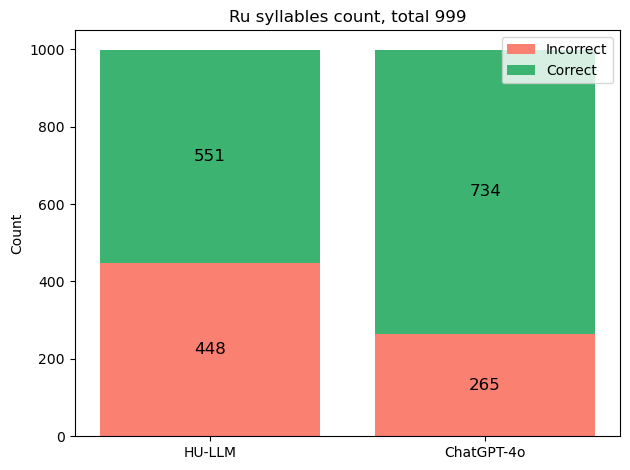

In [6]:
import matplotlib.pyplot as plt
import numpy as np

hu = 'HU-LLM'
gpt = 'ChatGPT-4o'

# Data
groups = [hu, gpt]
true_counts = [551, 734]
false_counts = [448, 265]

# Bar positions
x = np.arange(len(groups))

# Create the plot
fig, ax = plt.subplots()
bars_false = ax.bar(x, false_counts, label='Incorrect', color='salmon')
bars_true = ax.bar(x, true_counts, bottom=false_counts, label='Correct', color='mediumseagreen')

# Add larger text labels inside the bars
for i in range(len(groups)):
    ax.text(x[i], false_counts[i] / 2, str(false_counts[i]), 
            ha='center', va='center', color='black', fontsize=12)
    ax.text(x[i], false_counts[i] + true_counts[i] / 2, str(true_counts[i]), 
            ha='center', va='center', color='black', fontsize=12)

# Customize the plot
ax.set_ylabel('Count')
ax.set_title('Ru syllables count, total 999')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend()

# Layout adjustment
plt.tight_layout()
plt.show()


In [7]:
from scipy.stats import chi2_contingency

# Construct contingency table
observed = np.array([
    [551, 448],  # P1
    [734, 265]   # P2
])

chi2, p, dof, expected = chi2_contingency(observed)

print(f"Chi-square = {chi2:.3f}")
print(f"p-value = {p:.4f}")
print(f"Degrees of freedom = {dof}")
print("Expected counts:\n", expected)

Chi-square = 72.235
p-value = 0.0000
Degrees of freedom = 1
Expected counts:
 [[642.5 356.5]
 [642.5 356.5]]


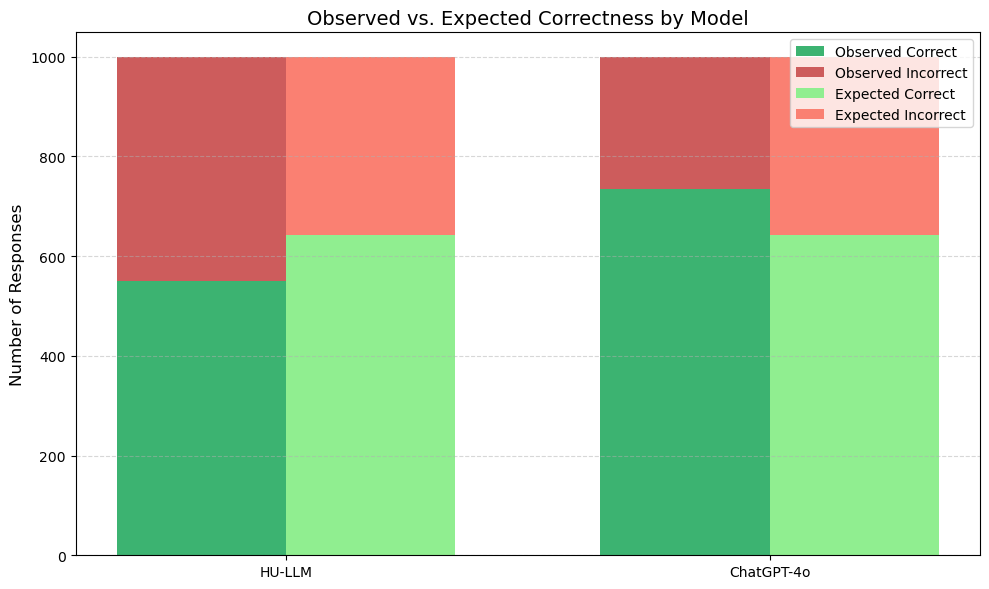

In [8]:
# Observed counts (from your results)
observed_correct = np.array([551, 734])     # P1, P2
observed_incorrect = np.array([448, 265])   # P1, P2

# Expected counts (from chi-square test)
expected_correct = np.array([642.5, 642.5])
expected_incorrect = np.array([356.5, 356.5])

# Participant labels
labels = groups
x = np.arange(len(labels))
width = 0.35  # Width of each bar

# === Plot ===
fig, ax = plt.subplots(figsize=(10, 6))

# Observed bars
bar_obs_correct = ax.bar(x - width/2, observed_correct, width, label='Observed Correct', color='mediumseagreen')
bar_obs_incorrect = ax.bar(x - width/2, observed_incorrect, width,
                           bottom=observed_correct, label='Observed Incorrect', color='indianred')

# Expected bars
bar_exp_correct = ax.bar(x + width/2, expected_correct, width, label='Expected Correct', color='lightgreen')
bar_exp_incorrect = ax.bar(x + width/2, expected_incorrect, width,
                           bottom=expected_correct, label='Expected Incorrect', color='salmon')

# Labels and styling
ax.set_ylabel('Number of Responses', fontsize=12)
ax.set_title('Observed vs. Expected Correctness by Model', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(loc='upper right')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Summary to the above chi-square test: ChatGPT gave more correct answers than HU-LLM, and this difference is unlikely due to chance (`p < 0.005`). Expected counts are printed out, and they are different from those that I got. 

Todo: 
- all stat
- part of speech tagging
- checking per attempt

### Freq stat

In [9]:
stat_df = pd.DataFrame({'baseline': ready_df['Baseline count'], 
                        'HU' : ready_df['HU count'], 
                        'GPT' : ready_df['GPT count']})

In [10]:
from scipy.stats import pearsonr
import numpy as np

def freq_eval(baseline1, measured): 
    errors = measured - baseline1
    bias = np.mean(errors)
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    std_dev = np.std(errors)
    r, p = pearsonr(baseline1, measured)
    
    return {
        'Bias': bias,
        'MAE': mae,
        'RMSE': rmse,
        'StdDev': std_dev,
        'Pearson_r': r,
        'Pearson_p': p
    }

In [11]:
metrics_hu = freq_eval(stat_df['baseline'], stat_df['HU'])
metrics_gpt = freq_eval(stat_df['baseline'], stat_df['GPT'])

results_df = pd.DataFrame({
     hu : metrics_hu,
    gpt : metrics_gpt
}).T

results_df.round(3)

,Bias,MAE,RMSE,StdDev,Pearson_r,Pearson_p
HU-LLM,-0.530,0.554,0.875,0.697,0.972,0.0
ChatGPT-4o,-0.635,0.635,0.992,0.763,0.963,0.0


Raw results: ChatGPT seems more accurate, 74% correct compared to 53% by HU-LLM. But judging by 

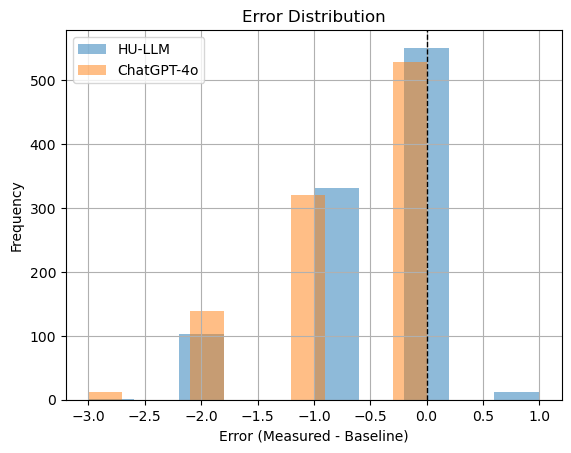

In [12]:
errors_p1 = stat_df['HU'] - stat_df['baseline']
errors_p2 = stat_df['GPT'] - stat_df['baseline']

plt.hist(errors_p1, bins=10, alpha=0.5, label=hu)
plt.hist(errors_p2, bins=10, alpha=0.5, label=gpt)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Error (Measured - Baseline)')
plt.ylabel('Frequency')
plt.title('Error Distribution')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Example data
data = pd.DataFrame({
    'true_syllables': [3, 2, 5, 4, 1, 2],
    'participant_count': [3, 1, 4, 4, 1, 2]
})

# Predictor: true number of syllables
X = data[['true_syllables']]

# Target: participant's response
y = data['participant_count']

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Model parameters
print("Intercept:", model.intercept_)
print("Slope (sensitivity to true syllables):", model.coef_[0])

# Optional: predict and inspect residuals
data['predicted'] = model.predict(X)
data['residual'] = data['participant_count'] - data['predicted']
print(data)


### Bayesian stat 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, nu]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


array([<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'sigma'}>,
       <Axes: title={'center': 'nu'}>], dtype=object)

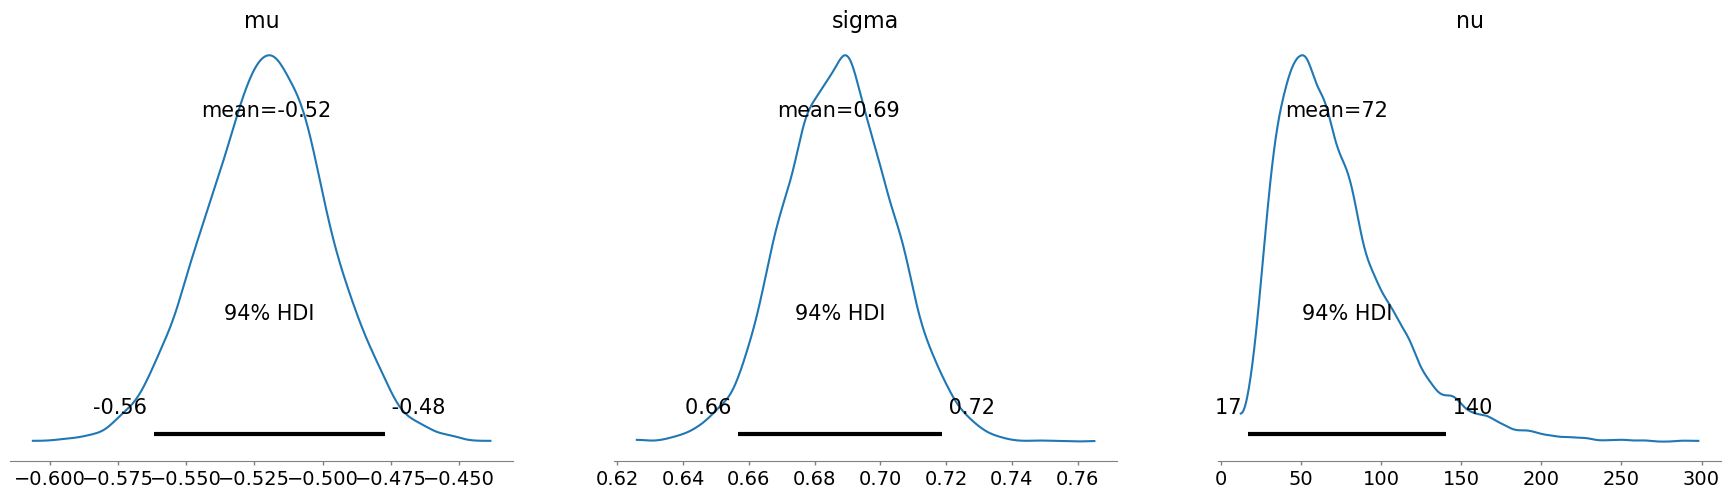

In [25]:
import pymc as pm
import arviz as az

with pm.Model() as model:
    # Prior for the mean error (bias)
    mu = pm.Normal("mu", mu=0, sigma=1)

    # Prior for scale (spread of errors)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Prior for degrees of freedom (t-distribution heaviness)
    nu = pm.Exponential("nu", 1/30)  # Smaller nu = heavier tails

    # Likelihood: observed errors follow Student's t
    obs = pm.StudentT("obs", mu=mu, sigma=sigma, nu=nu, observed=errors)

    # Sampling from the posterior
    trace = pm.sample(2000, return_inferencedata=True)

# Summary and posterior plots
az.summary(trace, var_names=["mu", "sigma", "nu"], kind="stats")
az.plot_posterior(trace, var_names=["mu", "sigma", "nu"])

Output from a Bayesian model of error is above. My question is: how much measured (by LLM) syllable count varies from the true count (from the web). For this, I estimate two parameters—mu and sigma. 

1) Mu is a mean of error, it is -0.53. The interpretation would be that LLM underestimates count by 0.53 syllables on average. Then there is HDI, which is the Highest Density Interval, it is \[-0.57, -0.49\]. 
 

## Part 2: Counting syllables in sentences and stress marking

Данные из акцентологического корпуса